In [5]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib.patches import Rectangle, Patch
from matplotlib.lines import Line2D
import numpy as np
from pathlib import Path

from matplotlib_style import apply_style, latex_figsize

In [6]:
RECT_HEIGHT = .25
HH = RECT_HEIGHT / 2  # Half Height of the Rectangle

# Y bounds to draw connector lines between rows
MID = 0.5  # middle row
row_bounds = np.array([[0 - HH, 0 + HH], [MID - HH, MID + HH], [1 - HH, 1 + HH]])
lower = [-HH, MID + HH]
upper = [MID - HH, 1 + HH]

INTERPRE_DUR = 175
PREICT_DUR = 60
INTERVENTION_DUR = 5
POSTICT_DUR = 60
INTERPOST_DUR = 180

INTERICT_HEIGHT = RECT_HEIGHT / 3
INTERICT_COLOR = '#34a1eb'  # turquoise
INTERPRE_COLOR = '#f4d35e'  # yellow
PREICT_COLOR = '#f4a261'  # orange
INTERVENTION_COLOR = '#e76f51'  # red-orange
SZR_COLOR = 'red'  # red
POSTICT_COLOR = '#b79ced'  # soft lavender
INTERPOST_COLOR = '#8e7cc3'  # muted purple

szrs = np.array([0, 107])
intervention_starts = szrs - INTERVENTION_DUR  # preictal-intervention boundaries
preict_starts = intervention_starts - PREICT_DUR
interpre_starts = preict_starts - INTERPRE_DUR
postict_starts = szrs
interpost_starts = postict_starts + POSTICT_DUR

In [7]:
def add_rect(x, row, width, **kwargs):
    height = kwargs.pop('height', RECT_HEIGHT)
    y = row - height / 2
    ax.add_patch(Rectangle([x, y], width, height, **kwargs))

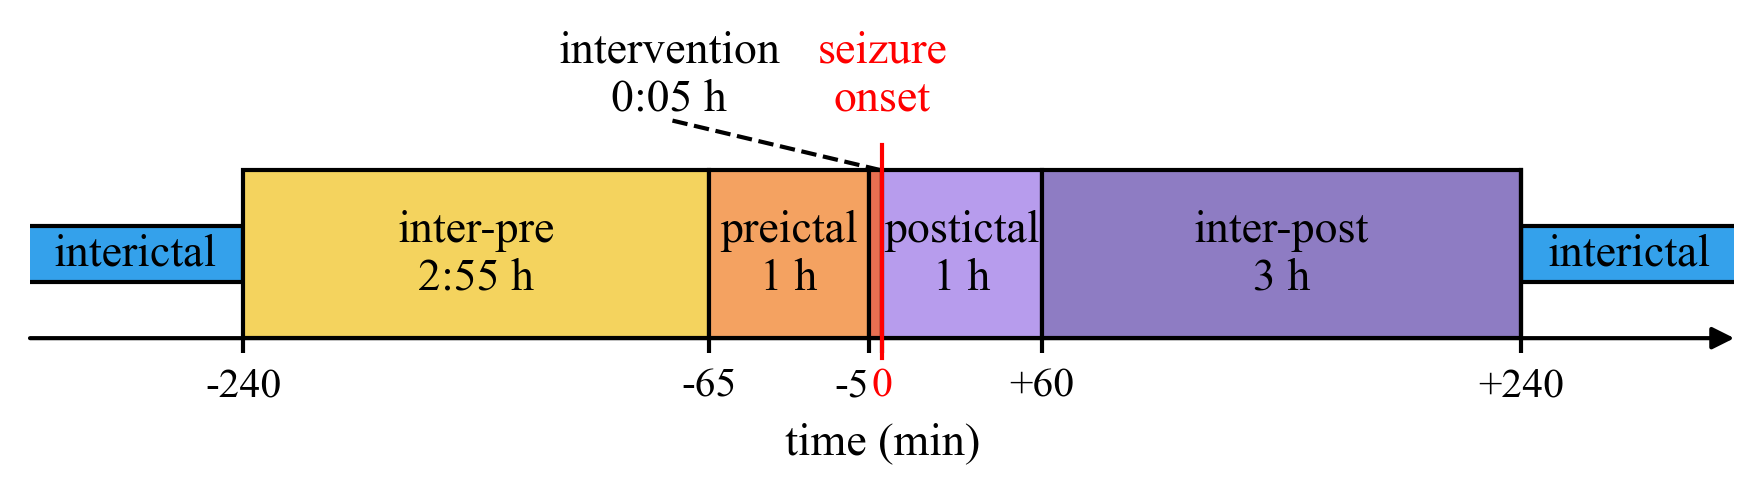

In [127]:
# ----------------------------------------------------------------------------------------
# Plotting Standard Periictal Intervals
# ----------------------------------------------------------------------------------------
apply_style(use_small_font=False)
fig, ax = plt.subplots(figsize=latex_figsize(height_ratio=0.25))

# Plot Seizure
ax.plot([0, 0], [-HH - 0.03, HH * 1.3], clip_on=False, color=SZR_COLOR, linewidth=1, zorder=10)


# ax.axvline(0, ymin=-.065, ymax=1, color=SZR_COLOR, linewidth=1, clip_on=False, zorder=10)

def draw_bound(x, **kwargs):
    default = dict(color='k', linewidth=1)
    default.update(kwargs)
    ax.plot([x, x], [-HH, HH], **default)


# ---- Draw Intervals
# Interictal:
add_rect(interpre_starts[0] - 200, 0, 200, facecolor=INTERICT_COLOR, height=INTERICT_HEIGHT, edgecolor='k')
ax.text(interpre_starts[0] - 10, 0, 'interictal', ha='right', va='center')

x = interpost_starts[0] + INTERPOST_DUR
draw_bound(x)
add_rect(x, 0, 200, facecolor=INTERICT_COLOR, height=INTERICT_HEIGHT, edgecolor='k')
ax.text(x + 10, 0, 'interictal', ha='left', va='center')

intervals = [
    ('inter-pre\n2:55 h', interpre_starts[0], INTERPRE_DUR, INTERPRE_COLOR),
    ('preictal\n1 h', preict_starts[0], PREICT_DUR, PREICT_COLOR),
    ('intervention', intervention_starts[0], INTERVENTION_DUR, INTERVENTION_COLOR),
    ('postictal\n1 h', postict_starts[0], POSTICT_DUR, POSTICT_COLOR),
    ('inter-post\n3 h', interpost_starts[0], INTERPOST_DUR, INTERPOST_COLOR),
]

for label, x, duration, color in intervals:
    # draw_bound(x)
    add_rect(x, 0, duration, facecolor=color, edgecolor='k')
    if label != 'intervention':
        ax.text(x + duration / 2, 0, label, ha='center', va='center', zorder=10)

# Intervention Label
ax.text(-80, .2, 'intervention\n0:05 h', ha='center', va='bottom')
ax.plot([-.5, -80], [HH, .2], linestyle='--', color='k', linewidth=1)
# Seizure Onset Label
ax.text(0, .2, 'seizure\nonset', ha='center', va='bottom', color=SZR_COLOR)

ax.set_xlabel('time (min)')
xlims = (-320, 320)
ax.set_xlim(xlims)
ax.tick_params(axis='x', width=1)
ax.set_xticks([-240, -65, -5, 0, 60, 240], ['-240', '-65', '-5', '0', '+60', '+240'])
# Get the tick labels and modify the ones you need
for i, label in enumerate(ax.get_xticklabels()):
    if label.get_text() == '0':
        label.set_color('red')
    elif label.get_text() == '-5':
        label.set_ha('right')  # Right-align to shift left

ax.set_ylim([-HH, RECT_HEIGHT])
ax.set_yticks([])

ax.annotate('', xytext=(xlims[0], -HH), xy=(xlims[1], -HH),
            arrowprops=dict(arrowstyle='-|>', shrinkA=0, shrinkB=0, facecolor='k'))

ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)

fig.subplots_adjust(top=0.7)
fig.tight_layout(pad=0)

plt.show(fig)

path = Path("~/Developer/MastersThesis/src/figures/intervals_around_seizure.pdf").expanduser()
# fig.savefig(path)

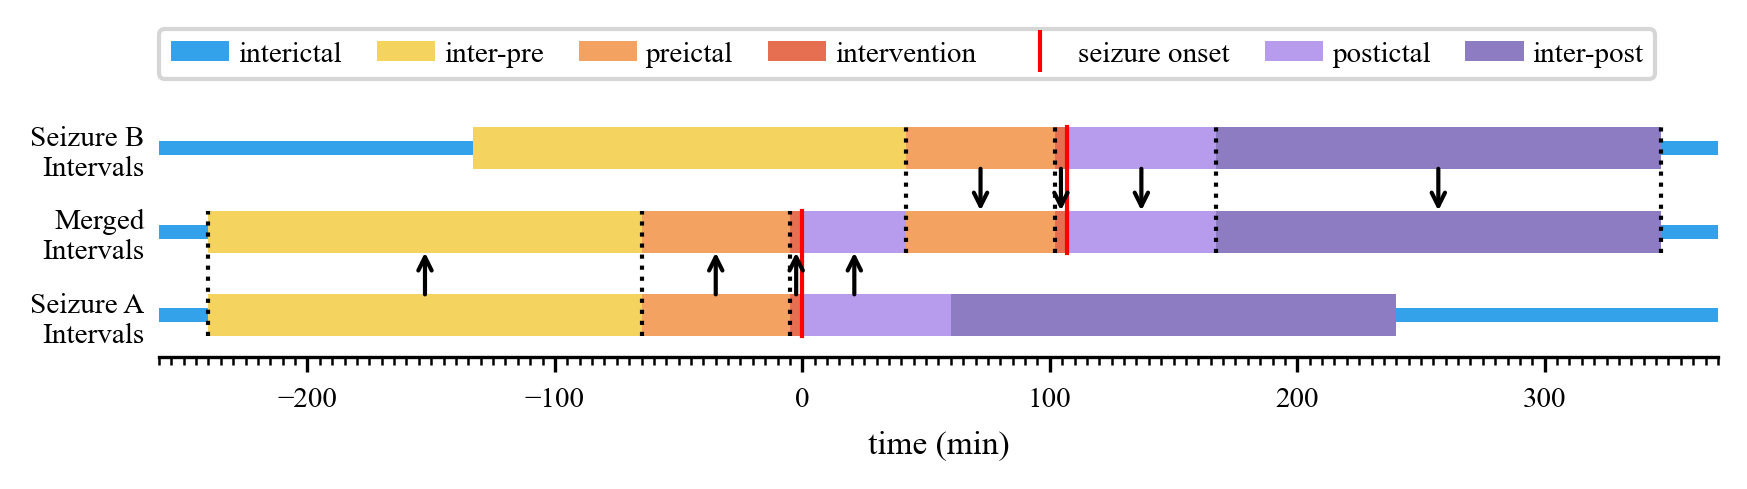

In [167]:
# ----------------------------------------------------------------------------------------
# Plotting Overlapping Intervals
# ----------------------------------------------------------------------------------------
apply_style(use_small_font=True)
fig, ax = plt.subplots(figsize=latex_figsize(height_ratio=0.25))
ax.set_xlabel('time (min)')
ax.xaxis.set_minor_locator(MultipleLocator(5))

xlims = (-260, 370)
ax.set_xlim(xlims)
ylims = (-HH * 2, 1 + HH * 2)
ax.set_ylim(ylims)

# Draw Seizures
ax.plot([szrs[0]] * 2, lower, color=SZR_COLOR, linewidth=1)
ax.plot([szrs[1]] * 2, upper, color=SZR_COLOR, linewidth=1)

# Draw Intervals for seizures A and B
for i in range(len(szrs)):
    add_rect(interpre_starts[i] - 200, i, 200, facecolor=INTERICT_COLOR, height=INTERICT_HEIGHT)
    add_rect(interpre_starts[i], i, INTERPRE_DUR, facecolor=INTERPRE_COLOR)
    add_rect(preict_starts[i], i, PREICT_DUR, facecolor=PREICT_COLOR)
    add_rect(intervention_starts[i], i, INTERVENTION_DUR, facecolor=INTERVENTION_COLOR)
    add_rect(postict_starts[i], i, POSTICT_DUR, facecolor=POSTICT_COLOR)
    add_rect(interpost_starts[i], i, INTERPOST_DUR, facecolor=INTERPOST_COLOR)
    add_rect(interpost_starts[i] + INTERPOST_DUR, i, 200, facecolor=INTERICT_COLOR, height=INTERICT_HEIGHT)


#% ------------------------------------------------------------------------------------------------
# Draw Intervals, Boundaries, and Arrow for Merged Intervals (Middle Row)
def draw_bound(x, ys):
    ax.plot([x, x], ys, color='k', linewidth=1, linestyle=':')


def draw_arrow(x, from_below: bool):
    if from_below:
        ys = (row_bounds[0, 1], row_bounds[1, 0])
    else:
        ys = (row_bounds[2, 0], row_bounds[1, 1])
    ax.annotate(
        '',
        xytext=(x, ys[0]), xy=(x, ys[1]),
        arrowprops=dict(arrowstyle='->', shrinkA=0, shrinkB=0))


intervals = [
    (interpre_starts[0], 'INTERPRE', 0),
    (preict_starts[0], 'PREICT', 0),
    (intervention_starts[0], 'INTERVENTION', 0),
    (postict_starts[0], 'POSTICT', 0),
    # ---- boundary
    (preict_starts[1], 'PREICT', 1),
    (intervention_starts[1], 'INTERVENTION', 1),
    (postict_starts[1], 'POSTICT', 1),
    (interpost_starts[1], 'INTERPOST', 1),
    (interpost_starts[1] + INTERPOST_DUR, 'INTERPOST', 1),  # sentinel for end
]

for i in range(len(intervals) - 1):
    x_cur, label_cur, origin_cur = intervals[i]
    x_next, _, _ = intervals[i + 1]
    duration = x_next - x_cur

    add_rect(x_cur, MID, duration, facecolor=eval(f'{label_cur}_COLOR'))

    if label_cur != 'POSTICT':
        draw_bound(x_cur, lower if origin_cur == 0 else upper)

    midpoint = (x_cur + x_next) / 2
    draw_arrow(midpoint, origin_cur == 0)

# Add final bound
draw_bound(x_next, upper)
# Draw Interictal
bounds = [intervals[0][0] - 200, intervals[-1][0]]
for b in bounds:
    add_rect(b, MID, 200, facecolor=INTERICT_COLOR, height=INTERICT_HEIGHT)

ax.set_yticks([0, 0.5, 1], ['Seizure A\nIntervals', 'Merged\nIntervals', 'Seizure B\nIntervals'])
ax.tick_params(axis='y', length=0)
# ax.yaxis.set_inverted(True)

ax.legend(
    handles=[
        Patch(facecolor=INTERICT_COLOR, label='interictal'),
        Patch(facecolor=INTERPRE_COLOR, label='inter-pre'),
        Patch(facecolor=PREICT_COLOR, label='preictal'),
        Patch(facecolor=INTERVENTION_COLOR, label='intervention'),
        Line2D([0], [0], color=SZR_COLOR, marker='|', markersize=10, linestyle='None', label='seizure onset'),
        Patch(facecolor=POSTICT_COLOR, label='postictal'),
        Patch(facecolor=INTERPOST_COLOR, label='inter-post'),
    ],
    ncols=7,
    loc='lower center',
    bbox_to_anchor=(0.48, 1.05),  # x=0.5 center, y>1 places it above the axes
    # frameon=False,
    handletextpad=0.3,
    columnspacing=1.2,
)

ax.spines[['top', 'right', 'left']].set_visible(False)

fig.tight_layout(pad=0)
plt.show()

path = Path("~/Developer/MastersThesis/src/figures/intervals_around_seizure_overlapping.pdf").expanduser()
fig.savefig(path)

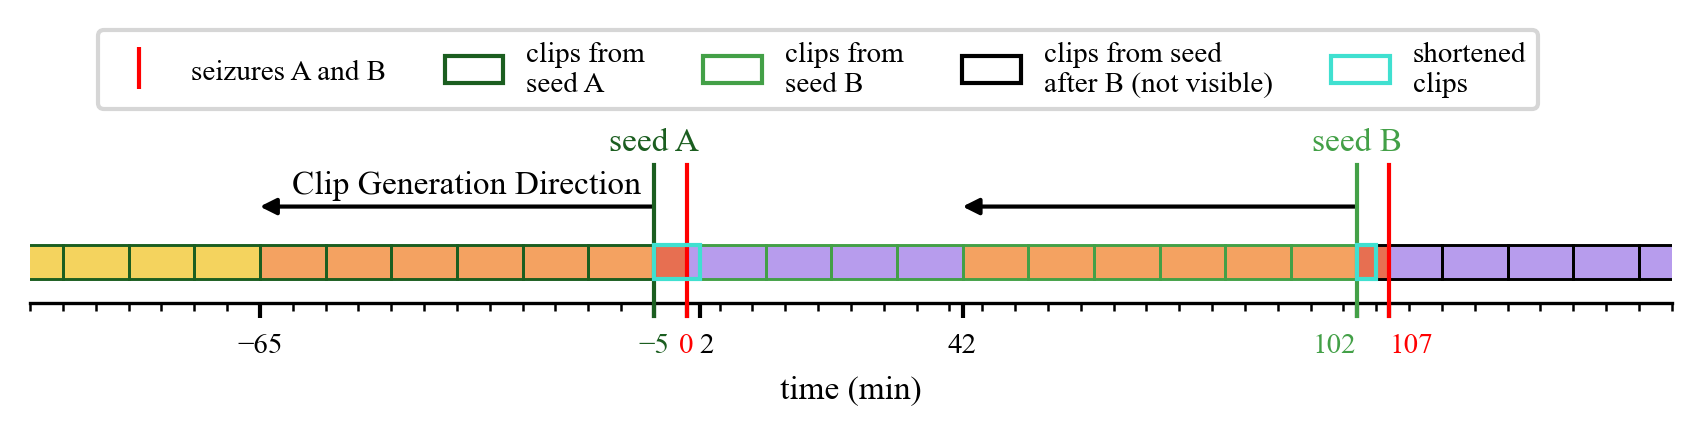

In [18]:
# ----------------------------------------------------------------------------------------
# Plotting Clip Generation
# ----------------------------------------------------------------------------------------

CLIP_DUR = 10
SEED_COLORS = ["#1B5E20", "#43A047", "black"]
SHORT_CLIP_COLOR = 'turquoise'

apply_style(use_small_font=True)
fig, ax = plt.subplots(figsize=latex_figsize(height_ratio=0.25))
xlims = [-100, 150]

# Draw Seizures
for i, szr in enumerate(szrs):
    ax.axvline(szr, ymin=-0.09, ymax=1, color=SZR_COLOR, linewidth=1, clip_on=False, zorder=9)
# Draw Clip Seeds
for i, seed in enumerate(intervention_starts):
    ax.axvline(seed, ymin=-0.09, ymax=1, color=SEED_COLORS[i], linewidth=1, clip_on=False, zorder=9)

# Draw Intervals
add_rect(interpre_starts[0], 0, INTERPRE_DUR, facecolor=INTERPRE_COLOR)
add_rect(preict_starts[0], 0, PREICT_DUR, facecolor=PREICT_COLOR)
add_rect(intervention_starts[0], 0, INTERVENTION_DUR, facecolor=INTERVENTION_COLOR)
add_rect(postict_starts[0], 0, POSTICT_DUR, facecolor=POSTICT_COLOR)
add_rect(preict_starts[1], 0, PREICT_DUR, facecolor=PREICT_COLOR)
add_rect(intervention_starts[1], 0, INTERVENTION_DUR, facecolor=INTERVENTION_COLOR)
add_rect(postict_starts[1], 0, POSTICT_DUR, facecolor=POSTICT_COLOR)

# ------------------------------------------------------------------------------------
# Plot full clips
# Clip starts by seizure:
later_szr = szrs[1] + 103
clip_starts_szr = [
    np.sort(np.arange(intervention_starts[0] - CLIP_DUR, xlims[0] - CLIP_DUR, -CLIP_DUR)),
    np.sort(np.arange(intervention_starts[1] - CLIP_DUR, intervention_starts[0], -CLIP_DUR)),
    np.sort(np.arange(later_szr - INTERVENTION_DUR - CLIP_DUR, intervention_starts[1], -CLIP_DUR))
]

for i, clip_starts in enumerate(clip_starts_szr):
    for cs in clip_starts:
        add_rect(cs, 0, CLIP_DUR, facecolor='none', edgecolor=SEED_COLORS[i], linewidth=0.7, zorder=8)

# Plot shortened clips
for i in range(len(clip_starts_szr) - 1):
    cs = clip_starts_szr[i][-1] + CLIP_DUR
    ce = clip_starts_szr[i + 1][0]
    add_rect(cs, 0, ce - cs, facecolor='none', edgecolor=SHORT_CLIP_COLOR, linewidth=1, zorder=10)

# ---- Plot arrows & labels for seeds
for i, start in enumerate(intervention_starts):
    ax.annotate(
        '',
        xytext=(start, .4), xy=(start - 60, .4),
        arrowprops=dict(arrowstyle='-|>', shrinkA=0, shrinkB=0, color='k'))

    if i == 0:
        ax.text(start - 2, 0.44, f'Clip Generation Direction', ha='right', va='bottom')

    ax.text(start, .75, f"seed {'A' if i==0 else 'B'}", ha='center', va='bottom', color=SEED_COLORS[i])

# ---- Handle Axis and Figure Properties
ax.legend(
    handles=[
        Line2D([0], [0], color=SZR_COLOR, marker='|', markersize=10, linestyle='None', label='seizures A and B'),
        Patch(edgecolor=SEED_COLORS[0], facecolor='none', label='clips from\nseed A'),
        Patch(edgecolor=SEED_COLORS[1], facecolor='none', label='clips from\nseed B'),
        Patch(edgecolor=SEED_COLORS[2], facecolor='none', label='clips from seed\nafter B (not visible)'),
        Patch(edgecolor=SHORT_CLIP_COLOR, facecolor='none', label='shortened\nclips'),

    ],
    ncols=5,
    loc='lower center',
    bbox_to_anchor=(0.48, 1.30),  # x=0.5 center, y>1 places it above the axes
    handleheight=RECT_HEIGHT * 4
)

ax.set_xlabel('time (min)')
ax.xaxis.set_minor_locator(MultipleLocator(5))
xticks = [-65, -5, 0, 2, 42, 102, 107]
ax.set_xticks(xticks)
ax.tick_params(axis='x', width=1)

# Get the tick labels and modify the ones you need
for i, (pos, label) in enumerate(zip(xticks, ax.get_xticklabels())):
    if pos == 0:
        label.set_color(SZR_COLOR)
    elif pos == 2:
        label.set_ha('left')
    elif pos == -5:
        label.set_color(SEED_COLORS[0])
    elif pos == 102:
        label.set_ha('right')
        label.set_color(SEED_COLORS[1])
    elif pos == 107:
        label.set_ha('left')
        label.set_color(SZR_COLOR)


ax.set_xlim(xlims)

ylims = [-.3, .7]
ax.set_ylim(ylims)
ax.set_yticks([])

fig.tight_layout(pad=0)
ax.spines[['top', 'right', 'left']].set_visible(False)

plt.show(fig)

path = Path("~/Developer/MastersThesis/src/figures/clip_generation.pdf").expanduser()
fig.savefig(path)